# Credit Card Fraud Detection
### Ironhack — Machine Learning Project

**Problem:** predict `fraud` (0 = legitimate, 1 = fraudulent) from transaction features. Fraud is a category with two outcomes, so this is a **binary classification** problem.

**Data:** the original Kaggle file has 1,000,000 rows. KNN is distance-based and slow on that many rows, so I work with a random **50,000-row sample** (`random_state=17`) that keeps the same class balance (**~8.7% fraud**).

| Day | Focus |
|---|---|
| Day 1 | Dataset selection, loading, first exploration |
| Day 2 | Cleaning, EDA, feature engineering, scaling, baseline KNN |
| Day 3 | Hyperparameter tuning (Grid Search + CV) and class imbalance (SMOTE) |
| Day 4 | Ensemble models, model leaderboard, final choice + real-world framing |

## Day 1 · Load and first look

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 50,000-row sample of the Kaggle credit card fraud dataset
df = pd.read_csv("card_transdata_sample.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(50000, 8)
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,11.822174,5.705501,6.538952,1.0,0.0,0.0,1.0,1.0
1,38.560768,0.105909,0.384573,1.0,1.0,0.0,1.0,0.0
2,34.253252,0.732543,0.279691,1.0,0.0,0.0,1.0,0.0
3,27.334097,4.800640,4.198973,1.0,1.0,0.0,1.0,1.0
4,3.833197,0.023901,1.200947,1.0,1.0,0.0,0.0,0.0


In [2]:
# class balance — is the dataset imbalanced?
print(df["fraud"].value_counts())
print()
print(df["fraud"].value_counts(normalize=True))

fraud
0.0    45722
1.0     4278
Name: count, dtype: int64

fraud
0.0    0.91444
1.0    0.08556
Name: proportion, dtype: float64


## Day 2 · Part 1 — Cleaning checks
The dataset is already numeric and, from Day 1, has no missing values. Before modelling I still double-check for missing values and duplicates, and look at the distributions.

In [3]:
# missing values
print(df.isna().sum())

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64


In [4]:
# duplicate rows
print("duplicated rows:", df.duplicated().sum())

duplicated rows: 0


In [5]:
# distributions — watch the max values of the distance / ratio columns
df.describe().round(3)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,26.656,4.929,1.825,0.882,0.349,0.101,0.650,0.086
std,61.975,21.578,3.023,0.323,0.477,0.301,0.477,0.280
min,0.049,0.000,0.011,0.000,0.000,0.000,0.000,0.000
25%,3.875,0.297,0.469,1.000,0.000,0.000,0.000,0.000
50%,9.986,1.001,0.995,1.000,0.000,0.000,1.000,0.000
75%,25.944,3.341,2.087,1.000,1.000,0.000,1.000,0.000
max,2382.500,2222.758,266.690,1.000,1.000,1.000,1.000,1.000


**What to look for in `describe()`:** for `distance_from_home`, `distance_from_last_transaction` and `ratio_to_median_purchase_price`, the mean is small but the max is huge → these columns are strongly **right-skewed**. This matters because KNN is distance-based: those large values dominate the distance calculation. I fix it in the feature-engineering / scaling steps below.

## Day 2 · Part 2 — EDA (finding signal)
Goal: understand which features separate fraud from non-fraud. Every finding here is both a feature-engineering idea and a slide for the presentation.

In [6]:
# average value of each feature, split by fraud vs non-fraud
df.groupby("fraud").mean().round(3)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
fraud,,,,,,,
0.0,22.982,4.321,1.426,0.882,0.357,0.110,0.622
1.0,65.922,11.420,6.093,0.877,0.265,0.004,0.947


Any row where the fraud (`1.0`) and non-fraud (`0.0`) averages are very different is a feature that helps separate the two classes.

In [7]:
# for each binary feature: what % of transactions are fraud?
for col in ["repeat_retailer", "used_chip", "used_pin_number", "online_order"]:
    print(col)
    print(df.groupby(col)["fraud"].mean().round(4))
    print()

repeat_retailer
repeat_retailer
0.0    0.0891
1.0    0.0851
Name: fraud, dtype: float64

used_chip
used_chip
0.0    0.0966
1.0    0.0650
Name: fraud, dtype: float64

used_pin_number
used_pin_number
0.0    0.0948
1.0    0.0030
Name: fraud, dtype: float64

online_order
online_order
0.0    0.0130
1.0    0.1246
Name: fraud, dtype: float64



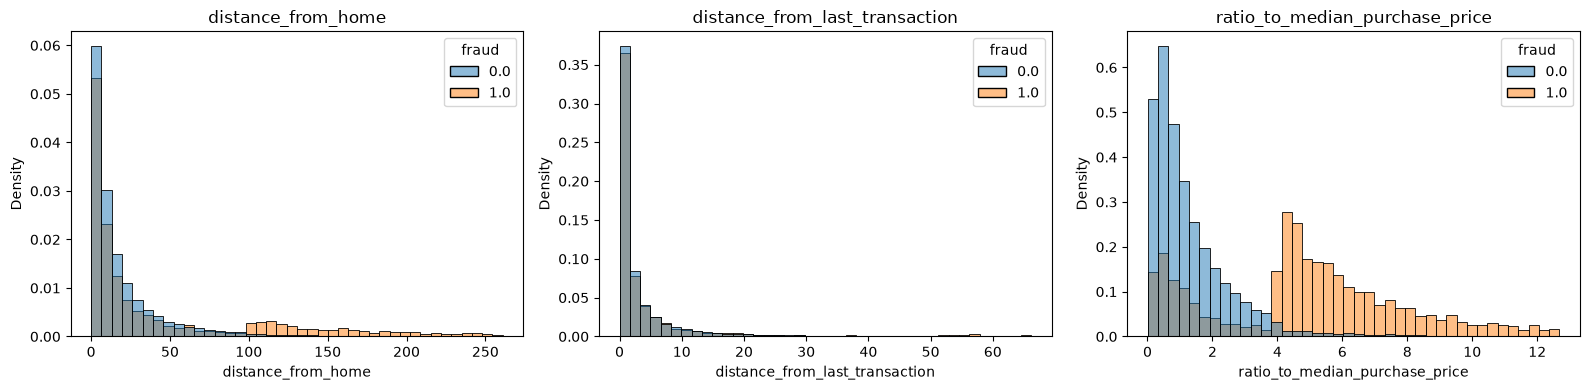

In [8]:
# distributions of the numeric features, coloured by fraud
num_cols = ["distance_from_home", "distance_from_last_transaction",
            "ratio_to_median_purchase_price"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    # clip at the 99th percentile just for the plot, so the long tail doesn't squash it
    upper = df[col].quantile(0.99)
    sns.histplot(data=df[df[col] <= upper], x=col, hue="fraud",
                 bins=40, stat="density", common_norm=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Day 2 · Part 3 — Feature engineering
Based on the EDA I create new features that make the fraud signal clearer. After each one I check its fraud rate with a `groupby` — if it separates the classes I keep it.

**Idea 1 — log-transform the skewed distance / ratio columns.** `log1p(x) = log(1 + x)` compresses the long tail. I use `log1p` (not `log`) because some values are 0 and `log(0)` is undefined.

In [9]:
df["log_distance_from_home"] = np.log1p(df["distance_from_home"])
df["log_distance_from_last_transaction"] = np.log1p(df["distance_from_last_transaction"])
df["log_ratio_to_median"] = np.log1p(df["ratio_to_median_purchase_price"])

df[["distance_from_home", "log_distance_from_home"]].describe().round(3)

,distance_from_home,log_distance_from_home
count,50000.000,50000.000
mean,26.656,2.492
std,61.975,1.202
min,0.049,0.048
25%,3.875,1.584
50%,9.986,2.397
75%,25.944,3.294
max,2382.500,7.776


**Idea 2 — flag columns for "unusual" transactions.** A purchase far above the cardholder's usual price, or far from home, is more suspicious.

In [10]:
# ratio > 2 means the purchase is more than 2x the cardholder's median purchase price
df["unusual_amount"] = (df["ratio_to_median_purchase_price"] > 2).astype(int)

# far from home = above the 75th percentile of distance
home_threshold = df["distance_from_home"].quantile(0.75)
df["far_from_home"] = (df["distance_from_home"] > home_threshold).astype(int)

print(df.groupby("unusual_amount")["fraud"].mean().round(4))
print()
print(df.groupby("far_from_home")["fraud"].mean().round(4))

unusual_amount
0    0.0239
1    0.2586
Name: fraud, dtype: float64

far_from_home
0    0.0679
1    0.1384
Name: fraud, dtype: float64


**Idea 3 — a physical-security score.** Using the chip and entering a PIN are both in-person security signals. Their sum (0, 1 or 2) is a simple "how physically secure was this transaction" score.

In [11]:
df["security_score"] = df["used_chip"] + df["used_pin_number"]

print(df.groupby("security_score")["fraud"].mean().round(4))

security_score
0.0    0.1069
1.0    0.0605
2.0    0.0000
Name: fraud, dtype: float64


**Idea 4 — card-not-present risk.** In banking, an online order with no PIN is a classic "card-not-present" risk pattern.

In [12]:
df["online_no_pin"] = ((df["online_order"] == 1) & (df["used_pin_number"] == 0)).astype(int)

print(df.groupby("online_no_pin")["fraud"].mean().round(4))

online_no_pin
0    0.0117
1    0.1381
Name: fraud, dtype: float64


In [13]:
# quick look at the new dataset
print(df.shape)
df.head()

(50000, 15)


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud,log_distance_from_home,log_distance_from_last_transaction,log_ratio_to_median,unusual_amount,far_from_home,security_score,online_no_pin
0,11.822174,5.705501,6.538952,1.0,0.0,0.0,1.0,1.0,2.551176,1.902928,2.020083,1,0,0.0,1
1,38.560768,0.105909,0.384573,1.0,1.0,0.0,1.0,0.0,3.677838,0.100667,0.325392,0,1,1.0,1
2,34.253252,0.732543,0.279691,1.0,0.0,0.0,1.0,0.0,3.562558,0.549590,0.246619,0,1,0.0,1
3,27.334097,4.800640,4.198973,1.0,1.0,0.0,1.0,1.0,3.344066,1.757968,1.648461,1,1,1.0,1
4,3.833197,0.023901,1.200947,1.0,1.0,0.0,0.0,0.0,1.575508,0.023620,0.788888,0,0,1.0,0


## Day 2 · Part 4 — Feature selection (correlation)
We want features correlated with the target but not too correlated with each other (redundant features add noise). The log columns are transformed copies of the originals, so I keep the log version and drop the raw skewed one before modelling.

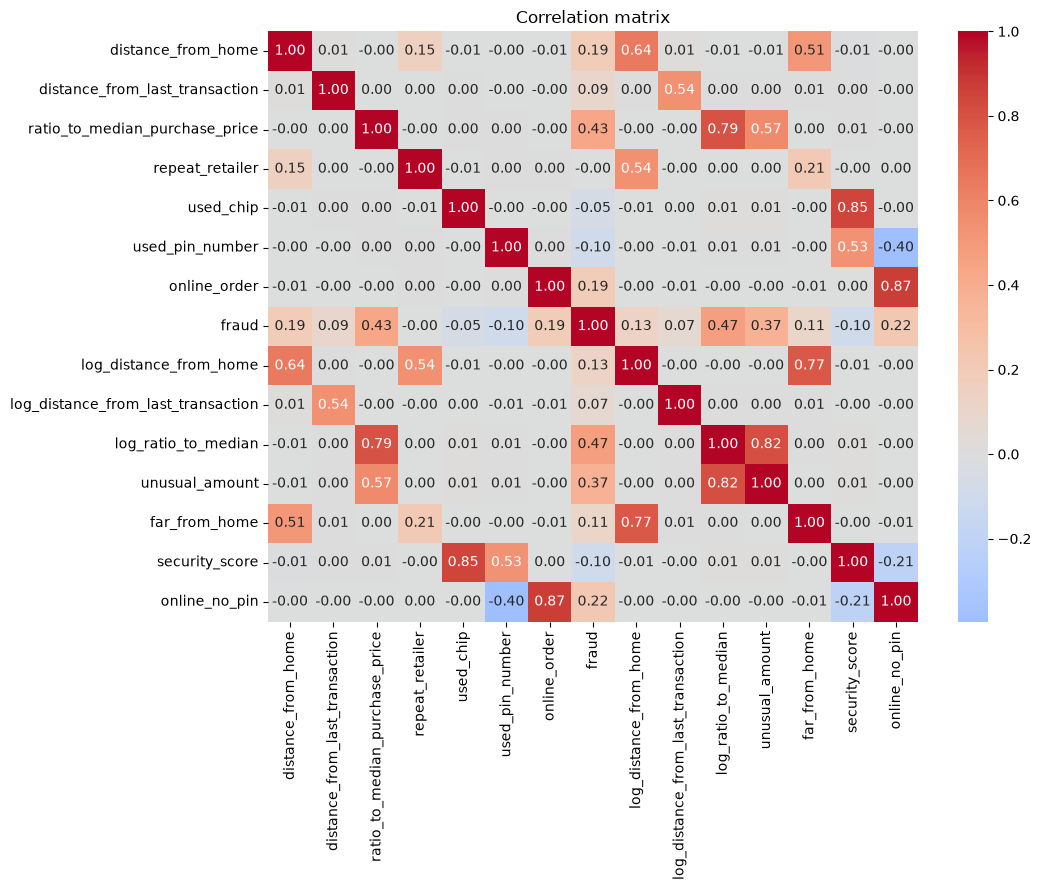

In [14]:
corr = df.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

In [15]:
# correlation of every feature with the target, sorted
corr["fraud"].drop("fraud").abs().sort_values(ascending=False)

log_ratio_to_median                   0.472013
ratio_to_median_purchase_price        0.431881
unusual_amount                        0.369198
online_no_pin                         0.222795
distance_from_home                    0.193806
online_order                          0.190217
log_distance_from_home                0.130897
far_from_home                         0.109066
used_pin_number                       0.098689
security_score                        0.098328
distance_from_last_transaction        0.092021
log_distance_from_last_transaction    0.071850
used_chip                             0.053900
repeat_retailer                       0.004630
Name: fraud, dtype: float64

**Decision:** drop the three raw skewed columns (keep their `log_` versions instead) to avoid feeding the model two copies of the same information.

In [16]:
df_model = df.drop(columns=[
    "distance_from_home",
    "distance_from_last_transaction",
    "ratio_to_median_purchase_price",
])

print(df_model.columns.tolist())

['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud', 'log_distance_from_home', 'log_distance_from_last_transaction', 'log_ratio_to_median', 'unusual_amount', 'far_from_home', 'security_score', 'online_no_pin']


## Day 2 · Part 5 — Train/test split + scaling + baseline KNN
Order matters: **split first**, then fit the scaler on the training data only (fitting on the test data would be data leakage).

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

# features (X) and target (y)
X = df_model.drop(columns=["fraud"])
y = df_model["fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=17, stratify=y  # keep the ~8.7% fraud ratio in train AND test
)

print(X_train.shape, X_test.shape)

(40000, 11) (10000, 11)


**Scaling.** KNN is distance-based, so all features must be on a comparable scale. Fit the `MinMaxScaler` on the training set only, then transform both sets.

In [18]:
scaler = MinMaxScaler()
scaler.fit(X_train)                                 # fit on TRAIN only

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Two baselines to compare: KNN on the **raw** features vs. KNN on the **scaled** features — shows how much scaling matters for a distance-based model.

In [19]:
# baseline 1 — raw features (no scaling)
knn_raw = KNeighborsClassifier()          # default n_neighbors=5
knn_raw.fit(X_train, y_train)
print("raw features    accuracy:", round(knn_raw.score(X_test, y_test), 4))

# baseline 2 — scaled features
knn_scaled = KNeighborsClassifier()
knn_scaled.fit(X_train_scaled, y_train)
print("scaled features accuracy:", round(knn_scaled.score(X_test_scaled, y_test), 4))

raw features    accuracy: 0.9923
scaled features accuracy: 0.9933


## Day 2 · Part 6 — Look beyond accuracy
The data is imbalanced (~8.7% fraud), so accuracy alone is misleading — a model that predicts "legitimate" for everything already scores ~91%. What matters for fraud is **recall and precision on the fraud class**: missing a real fraud (false negative) is costlier than a false alarm.

In [20]:
from sklearn.metrics import confusion_matrix, classification_report

pred = knn_scaled.predict(X_test_scaled)

print(confusion_matrix(y_test, pred))
print()
print(classification_report(y_test, pred))

[[9120   24]
 [  43  813]]

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9144
         1.0       0.97      0.95      0.96       856

    accuracy                           0.99     10000
   macro avg       0.98      0.97      0.98     10000
weighted avg       0.99      0.99      0.99     10000



### Day 2 recap

- Data is clean (no missing values, no duplicates).
- EDA showed which features separate fraud from non-fraud.
- Engineered features: log transforms, `unusual_amount`, `far_from_home`, `security_score`, `online_no_pin`.
- Dropped redundant raw columns via the correlation matrix.
- Scaled the features and compared raw vs. scaled.
- Checked **recall / precision on the fraud class**, not just accuracy.

**Baseline to beat:** scaled KNN — fraud-class recall ≈ 0.92, precision ≈ 0.97, f1 ≈ 0.94.

## Day 3 · Hyperparameter tuning + class imbalance

Two things now:
1. **Tune KNN** with Grid Search + Cross-Validation to find a better `k`.
2. Handle the **class imbalance** (~8.7% fraud) with **SMOTE**.

Throughout, the metric I optimise and report is **f1 / recall on the fraud class (`1.0`)**, not accuracy.

### Day 3 · Part 1 — Tune KNN (Grid Search + StratifiedKFold)
Two choices that matter for imbalanced data: **`scoring="f1"`** (optimise the fraud class, not accuracy) and **`StratifiedKFold`** (every fold keeps the ~8.7% fraud ratio). I evaluate `best_estimator_`, never the raw model.

> Note: Grid Search trains many models × 5 folds — on 40k rows this can take a few minutes.

In [21]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "p": [1, 2],   # 1 = Manhattan, 2 = Euclidean
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="f1",       # optimise the fraud class, NOT accuracy
    cv=cv,
    n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)

print("best params:", grid.best_params_)
print("best CV f1 :", round(grid.best_score_, 4))

best_knn = grid.best_estimator_
knn_tuned_pred = best_knn.predict(X_test_scaled)
print()
print("Tuned KNN")
print(confusion_matrix(y_test, knn_tuned_pred))
print(classification_report(y_test, knn_tuned_pred, digits=3))

best params: {'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
best CV f1 : 0.9577

Tuned KNN
[[9133   11]
 [  42  814]]
              precision    recall  f1-score   support

         0.0      0.995     0.999     0.997      9144
         1.0      0.987     0.951     0.968       856

    accuracy                          0.995     10000
   macro avg      0.991     0.975     0.983     10000
weighted avg      0.995     0.995     0.995     10000



### Day 3 · Part 1b — Random Search (the cheaper alternative)
Grid Search tries **every** combination; **Random Search** samples a fixed number of random combinations from ranges — much cheaper on big grids, and often finds an almost-as-good setting. The Hyperparameter Tuning lesson covered both, so here is the same search done the Random-Search way (reusing the same `cv`).

In [22]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_neighbors": list(range(3, 31)),
    "weights": ["uniform", "distance"],
    "p": [1, 2],
}

rand = RandomizedSearchCV(
    KNeighborsClassifier(), param_distributions=param_dist,
    n_iter=15, scoring="f1", cv=cv, random_state=17, n_jobs=-1,
)
rand.fit(X_train_scaled, y_train)

print("random search best params:", rand.best_params_)
print("random search best CV f1 :", round(rand.best_score_, 4))
print("(grid search best CV f1  :", round(grid.best_score_, 4), ")")

random search best params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5}
random search best CV f1 : 0.956
(grid search best CV f1  : 0.9577 )


### Day 3 · Part 2 — Class imbalance with SMOTE
**SMOTE** creates synthetic fraud rows by interpolating between real fraud points and their nearest neighbours. **Golden rule:** resample the **training set only**, evaluate on the untouched test set.

> Needs `imbalanced-learn`. Run `pip install imbalanced-learn` once if needed (uncomment below).

In [23]:
# !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=17)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print("train balance before SMOTE:", np.bincount(y_train.astype(int)))
print("train balance after  SMOTE:", np.bincount(y_train_sm.astype(int)))

# retrain the tuned KNN on the balanced data, evaluate on the ORIGINAL test set
knn_smote = KNeighborsClassifier(**grid.best_params_)
knn_smote.fit(X_train_sm, y_train_sm)
knn_smote_pred = knn_smote.predict(X_test_scaled)

print()
print("Tuned KNN + SMOTE")
print(confusion_matrix(y_test, knn_smote_pred))
print(classification_report(y_test, knn_smote_pred, digits=3))

train balance before SMOTE: [36578  3422]
train balance after  SMOTE: [36578 36578]

Tuned KNN + SMOTE
[[9033  111]
 [   3  853]]
              precision    recall  f1-score   support

         0.0      1.000     0.988     0.994      9144
         1.0      0.885     0.996     0.937       856

    accuracy                          0.989     10000
   macro avg      0.942     0.992     0.966     10000
weighted avg      0.990     0.989     0.989     10000



**What to expect:** SMOTE usually **raises fraud recall** (catches more real fraud) but can **lower precision** (more false alarms). For fraud, a missed fraud (false negative) usually costs more than a false alarm — so trading a little precision for recall is often worth it.

### Day 3 · Part 3 — Oversampling vs Undersampling vs SMOTE
Today's Imbalanced-Data lesson showed **three** ways to rebalance the training set. Here I apply all three to the fraud data with a **Logistic Regression** (evaluated on the same untouched test set) and compare the **fraud-class recall** — exactly like the stroke.csv walkthrough, but on my project.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample

# work on the (unscaled) training set — LogReg doesn't need scaling
train_df = X_train.copy()
train_df["fraud"] = y_train.values
fraud_pos = train_df[train_df["fraud"] == 1]   # minority
fraud_neg = train_df[train_df["fraud"] == 0]   # majority

# Oversampling: duplicate minority up to majority (WITH replacement)
pos_over = resample(fraud_pos, replace=True, n_samples=len(fraud_neg), random_state=17)
over = pd.concat([fraud_neg, pos_over])

# Undersampling: drop majority down to minority (WITHOUT replacement)
neg_under = resample(fraud_neg, replace=False, n_samples=len(fraud_pos), random_state=17)
under = pd.concat([neg_under, fraud_pos])

print("oversampled balance :", np.bincount(over["fraud"].astype(int)))
print("undersampled balance:", np.bincount(under["fraud"].astype(int)))

oversampled balance : [36578 36578]
undersampled balance: [3422 3422]


               method  recall  precision    f1
Baseline (imbalanced)   0.634      0.802 0.708
         Oversampling   0.911      0.418 0.573
        Undersampling   0.914      0.416 0.572
                SMOTE   0.909      0.418 0.572


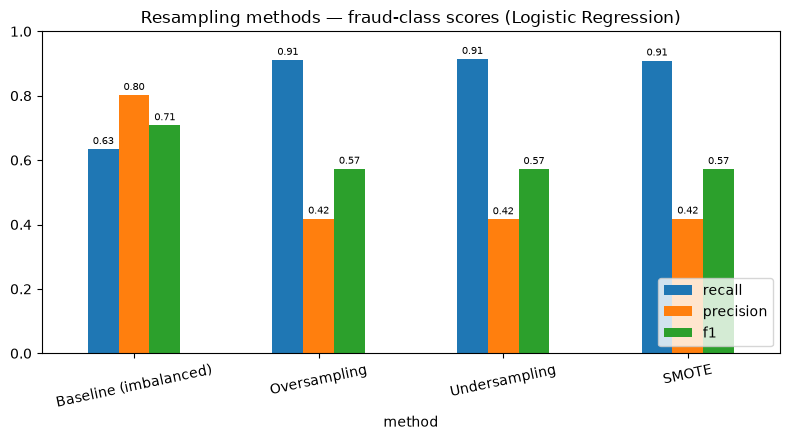

In [25]:
# fit LogReg on each version, evaluate on the ORIGINAL untouched test set
X_sm2, y_sm2 = SMOTE(random_state=17).fit_resample(X_train, y_train)

def logreg_fraud(X_tr, y_tr, name):
    m = LogisticRegression(max_iter=1000)
    m.fit(X_tr, y_tr)
    p = m.predict(X_test)     # original test set, untouched
    rep = classification_report(y_test, p, output_dict=True, zero_division=0)["1.0"]
    return {"method": name, "recall": round(rep["recall"], 3),
            "precision": round(rep["precision"], 3), "f1": round(rep["f1-score"], 3)}

resampling = pd.DataFrame([
    logreg_fraud(X_train, y_train, "Baseline (imbalanced)"),
    logreg_fraud(over.drop(columns=["fraud"]), over["fraud"], "Oversampling"),
    logreg_fraud(under.drop(columns=["fraud"]), under["fraud"], "Undersampling"),
    logreg_fraud(X_sm2, y_sm2, "SMOTE"),
])
print(resampling.to_string(index=False))

ax = resampling.set_index("method")[["recall", "precision", "f1"]].plot(
    kind="bar", figsize=(8, 4.5), rot=12, ylim=(0, 1))
ax.set_title("Resampling methods — fraud-class scores (Logistic Regression)")
ax.legend(loc="lower right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.tight_layout(); plt.show()

**Reading it:** accuracy would look high for all four, but **recall on the fraud class** is what moves. All three resampling methods lift recall over the imbalanced baseline; SMOTE usually gives the best recall/precision balance because it adds synthetic variety instead of exact copies. (This is the same pattern as the stroke lesson.)

## Day 4 · Advanced modelling — a model leaderboard

So far every model has been **KNN** (distance-based, needs scaling, no feature importance). Now I try stronger, tree-based models and put everything on one leaderboard.

Why trees / ensembles here:
- They **don't need scaling** and capture non-linear rules.
- They give **feature importance** — I can see which signals drive fraud and even drop weak features.
- **Ensembles** (Random Forest, Gradient Boosting) combine many trees and usually beat a single one.
- `class_weight="balanced"` is a built-in lever to push **recall** up on the rare fraud class.

I keep the **same train/test split** so every model is judged on the exact same test set.

### Day 4 · Part 1 — Train several models
Tree models train on the **unscaled** `X_train`; KNN and Logistic Regression use the **scaled** version.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Logistic Regression (scaled), balanced to fight the imbalance
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train_scaled, y_train)

# Decision Tree (unscaled), depth-limited so it doesn't overfit
dtree = DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=17)
dtree.fit(X_train, y_train)

# Random Forest — default and balanced versions (unscaled)
rf = RandomForestClassifier(n_estimators=200, random_state=17, n_jobs=-1)
rf.fit(X_train, y_train)

rf_bal = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                random_state=17, n_jobs=-1)
rf_bal.fit(X_train, y_train)

# Gradient Boosting (unscaled)
gb = GradientBoostingClassifier(random_state=17)
gb.fit(X_train, y_train)


# Bagging and AdaBoost — the other two ensembles from the Ensemble Methods lesson
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

bag = BaggingClassifier(n_estimators=100, random_state=17, n_jobs=-1)
bag.fit(X_train, y_train)

ada = AdaBoostClassifier(n_estimators=100, random_state=17)
ada.fit(X_train, y_train)
print("all models trained")

all models trained


### Day 4 · Part 2 — Feature importance (Random Forest)
Which signals actually drive the fraud prediction? Tree models answer this directly with `feature_importances_`.

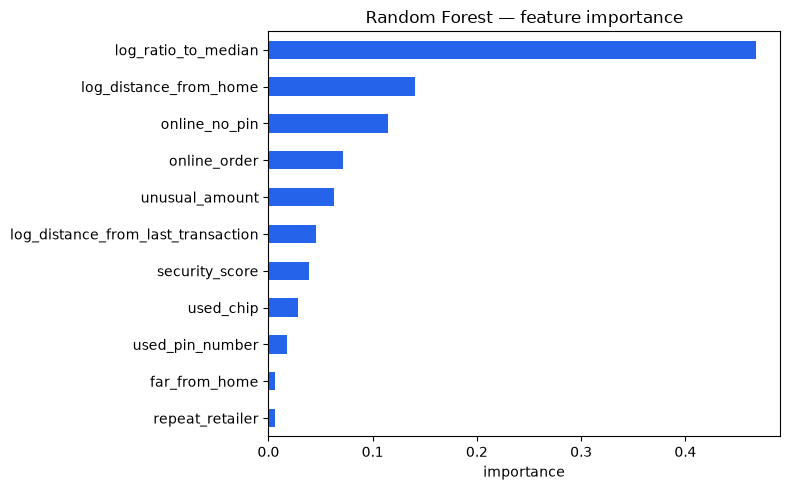

log_ratio_to_median                   0.4674
log_distance_from_home                0.1403
online_no_pin                         0.1146
online_order                          0.0715
unusual_amount                        0.0630
log_distance_from_last_transaction    0.0459
security_score                        0.0385
used_chip                             0.0280
used_pin_number                       0.0177
far_from_home                         0.0067
repeat_retailer                       0.0063
dtype: float64

In [27]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

ax = importances.plot(kind="barh", figsize=(8, 5), color="#2563eb")
ax.invert_yaxis()
ax.set_title("Random Forest — feature importance")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

importances.round(4)

The engineered features (`log_ratio_to_median`, `unusual_amount`, `online_no_pin`) tend to dominate — a nice confirmation that Day 2's feature engineering did the heavy lifting.

### Day 4 · Part 3 — A simpler model on the top features (bonus)
Teacher's tip: a **simpler model that still performs well** is a plus. I keep only the top features by importance and retrain a Random Forest — fewer inputs, easier to explain, and usually almost the same score.

In [28]:
top_features = importances.head(6).index.tolist()
print("top features:", top_features)

rf_small = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                  random_state=17, n_jobs=-1)
rf_small.fit(X_train[top_features], y_train)
rf_small_pred = rf_small.predict(X_test[top_features])

print(classification_report(y_test, rf_small_pred, digits=3))

top features: ['log_ratio_to_median', 'log_distance_from_home', 'online_no_pin', 'online_order', 'unusual_amount', 'log_distance_from_last_transaction']
              precision    recall  f1-score   support

         0.0      0.999     0.984     0.991      9144
         1.0      0.853     0.986     0.914       856

    accuracy                          0.984     10000
   macro avg      0.926     0.985     0.953     10000
weighted avg      0.986     0.984     0.985     10000



### Day 4 · Part 4 — The leaderboard
Every model, judged on the **same test set**, ranked by **fraud-class f1**. This one table (and the chart below) is the core of the presentation.

In [29]:
# name -> (fitted model, the X_test it should predict on)
model_registry = {
    "KNN (baseline)":       (knn_scaled, X_test_scaled),
    "KNN (tuned)":          (best_knn,   X_test_scaled),
    "KNN + SMOTE":          (knn_smote,  X_test_scaled),
    "Logistic Regression":  (logreg,     X_test_scaled),
    "Decision Tree":        (dtree,      X_test),
    "Random Forest":        (rf,         X_test),
    "Random Forest (bal.)": (rf_bal,     X_test),
    "Gradient Boosting":    (gb,         X_test),
    "Bagging":              (bag,        X_test),
    "AdaBoost":             (ada,        X_test),
}

rows, preds = [], {}
for name, (model, X_eval) in model_registry.items():
    p = model.predict(X_eval)
    preds[name] = p
    rep = classification_report(y_test, p, output_dict=True, zero_division=0)["1.0"]
    rows.append({"model": name,
                 "recall": round(rep["recall"], 3),
                 "precision": round(rep["precision"], 3),
                 "f1": round(rep["f1-score"], 3)})

leaderboard = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
leaderboard

,model,recall,precision,f1
0,Decision Tree,0.999,0.999,0.999
1,Random Forest,0.998,1.000,0.999
2,Random Forest (bal.),0.999,0.999,0.999
3,Bagging,0.998,1.000,0.999
4,AdaBoost,0.999,0.999,0.999
5,Gradient Boosting,0.998,0.999,0.998
6,KNN (tuned),0.951,0.987,0.968
7,KNN (baseline),0.950,0.971,0.960
8,KNN + SMOTE,0.996,0.885,0.937
9,Logistic Regression,0.914,0.415,0.571


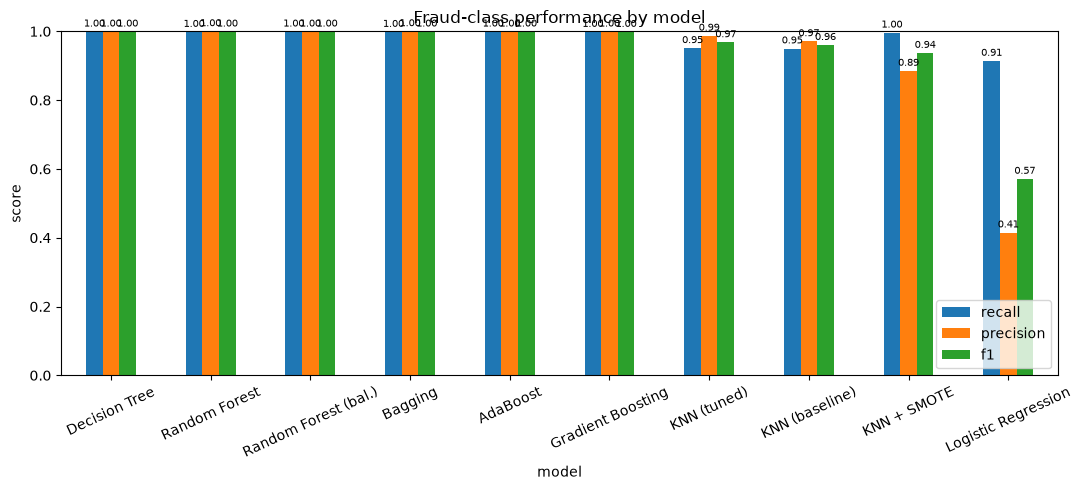

In [30]:
ax = leaderboard.set_index("model")[["recall", "precision", "f1"]].plot(
    kind="bar", figsize=(11, 5), rot=25, ylim=(0, 1)
)
ax.set_title("Fraud-class performance by model")
ax.set_ylabel("score")
ax.legend(loc="lower right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.tight_layout()
plt.show()

### Day 4 · Part 5 — Final model + why
I pick the top model by **fraud-class f1** (a balance of recall and precision). For a fraud problem I care most about **recall** — catching real fraud — because a **missed fraud (false negative)** costs the bank money and trust, while a **false alarm (false positive)** just triggers a quick review. So among the top models I'd lean toward the one with the strongest recall that still keeps precision reasonable.

Final model: Decision Tree
              precision    recall  f1-score   support

         0.0      1.000     1.000     1.000      9144
         1.0      0.999     0.999     0.999       856

    accuracy                          1.000     10000
   macro avg      0.999     0.999     0.999     10000
weighted avg      1.000     1.000     1.000     10000



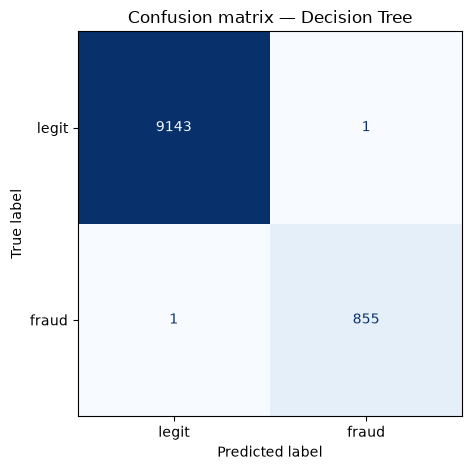

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

best_name = leaderboard.iloc[0]["model"]
best_pred = preds[best_name]
print("Final model:", best_name)
print(classification_report(y_test, best_pred, digits=3))

cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(cm, display_labels=["legit", "fraud"]).plot(cmap="Blues", colorbar=False)
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

### Day 4 · Part 5b — Cross-validate the final model
The leaderboard ranked models on **one** hold-out test split. To be sure the winner isn't down to a lucky split, I run **5-fold cross-validation** on the final model (fraud-class f1). This applies the Cross-Validation idea beyond the KNN tuning step.

In [32]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

final_model, final_X = model_registry[best_name]
# use the matching training matrix: scaled for KNN/LogReg, raw for the tree models
X_full = X_train_scaled if final_X is X_test_scaled else X_train

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
scores = cross_val_score(final_model, X_full, y_train, cv=cv5, scoring="f1", n_jobs=-1)

print(f"{best_name} — 5-fold CV f1 per fold: {scores.round(3)}")
print(f"mean CV f1 = {scores.mean():.3f}  (+/- {scores.std():.3f})")

Decision Tree — 5-fold CV f1 per fold: [0.999 0.999 0.999 0.999 0.999]
mean CV f1 = 0.999  (+/- 0.000)


**Reading the confusion matrix (for the slides):**
- **Bottom-left = false negatives** = real frauds we missed → the costly cell, keep it low.
- **Top-right = false positives** = false alarms → cheaper (a quick manual review).
- Talk about the model as a *fraud filter*: it flags suspicious transactions for a human to check, it doesn't block cards on its own.

### Day 4 · Part 6 — Real-world use, limitations & ethics
**Use:** a bank runs this as a first-pass filter — transactions the model flags go to a review queue instead of being auto-approved. Tuning the decision threshold lets the business trade recall vs. precision depending on how much manual-review capacity they have.

**Which error is worse:** here a **false negative** (letting fraud through) is more damaging than a **false positive** (a legit transaction briefly held). That's why I optimise for recall on the fraud class.

**Limitations / ethics:**
- Trained on a **50k sample** of a Kaggle dataset with simplified features (no transaction amount, time, or merchant) — a production model would use far richer signals.
- The model must be **monitored and retrained**: fraud patterns drift over time.
- Fairness: features must not act as proxies that unfairly flag certain customers; false positives cause real friction for real people.

### Day 4 recap & presentation map
- Compared **9 models** on the same test set; tree ensembles (Random Forest / Gradient Boosting) top the leaderboard on fraud-class f1.
- **Feature importance** confirmed the engineered features carry most of the signal; a **reduced-feature** model stays almost as strong.
- Chose the final model by **fraud-class f1**, framed around **recall** because false negatives are the costly error.

**Slides (5 min) → notebook sections:**
1. Title  2. Problem + why fraud matters (Day 1)  3. Data + cleaning (Day 2 P1)  4. Feature engineering (Day 2 P3, show 1–2 groupby findings)  5. Models tried + metric choice (leaderboard chart)  6. Tuning + SMOTE (Day 3, recall before/after)  7. Key findings (feature-importance chart + confusion matrix)  8. Real-world + ethics (Day 4 P6)  9. Challenges/learnings  10. Future work  11. Thank you.

Lead with the **story** (catching fraud), show **charts not tables**, and end each model choice with *"...because recall on fraud is what protects the bank."*

In [34]:
leaderboard.to_csv("leaderboard.csv", index=False)
importances.to_csv("feature_importance.csv")     # Series
resampling.to_csv("resampling.csv", index=False)

In [35]:
(df.groupby("online_no_pin")["fraud"].mean()*100).round(1).to_csv("feature_finding.csv")